# **Traffic Sign Classification Using Image-Based Deep Learning Techniques**

### **Description of the Dataset:**

The dataset is for Multi-Class, Single image classification.
There are two different folders:

**Train:**
It contains the training images of various classes.

**Test:**
It contains the images, of which your model should predict.

The images are of various Traffic sign images used in day to day life.

This dataset have following classes:
1. Caution:
This class consist of Traffic sign images that provide information related to varios caution about the road conditions.
2. Instruction:
This class consist of Traffic sign images that provide information regarding various instructions that should be followed on the road.
3. No Passing:
This class consist of Traffic sign images that provide information regarding whether or not go through the road.
4. OverSpeed:
This class consist of Traffic sign images that provide information regarding speed limit.


#**Part A: Implementing Convolutional Neural Network from Scratch**

In [ ]:
import zipfile

In [ ]:
with zipfile.ZipFile('/content/Traffic_Sign-20250415T134334Z-001.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/Traffic')

In [ ]:
!pip install tensorflow

## **Import Libraries**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

## **Data Understanding, Analysis, Visualization and Cleaning**

In [ ]:
# Define paths
train_dir = '/content/Traffic/Traffic_Sign/Train'
test_dir = '/content/Traffic/Traffic_Sign/Test'

**Dataset Class Distribution Analysis**

In [ ]:
for label_folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, label_folder)
    if os.path.isdir(folder_path):
        num_images = len([
            f for f in os.listdir(folder_path)
            if os.path.isfile(os.path.join(folder_path, f))
        ])
        print(f"Label: {label_folder}, Images: {num_images}")

Label: OverSpeed, Images: 5249
Label: Instructions, Images: 2848
Label: No Passing, Images: 5369
Label: Caution, Images: 2429


**Total Image in Train & Test**

In [ ]:
# Function to count images in a directory
def count_images(directory):
    image_count = 0
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):  # Add more extensions if needed
                image_count += 1
    return image_count

# Count images in train and test directories
train_image_count = count_images(train_dir)
test_image_count = count_images(test_dir)

# Print the results
print(f"Total images in train folder: {train_image_count}")
print(f"Total images in test folder: {test_image_count}")

Total images in train folder: 15895
Total images in test folder: 4


### **Visualization**

In [ ]:
import os
import random
import matplotlib.pyplot as plt

def visualize_data(train_data_dir):
    # Get the list of class directories
    class_dirs = [d for d in os.listdir(train_data_dir) ]
    print(class_dirs)

    # Select one image randomly from each class
    images = []
    labels = []
    for class_dir in class_dirs:
        class_path = os.path.join(train_data_dir, class_dir)
        image_files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
        random_image_file = random.choice(image_files)
        image_path = os.path.join(class_path, random_image_file)
        images.append(plt.imread(image_path))
        labels.append(class_dir)

    # Display the images in a grid format with two rows using matplotlib
    fig, axes = plt.subplots(2, len(class_dirs) // 2, figsize=(12, 6))
    for i, (image, label) in enumerate(zip(images, labels)):
        row = i // (len(class_dirs) // 2)
        col = i % (len(class_dirs) // 2)
        axes[row, col].imshow(image)
        axes[row, col].set_title(label)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

['OverSpeed', 'Instructions', 'No Passing', 'Caution']


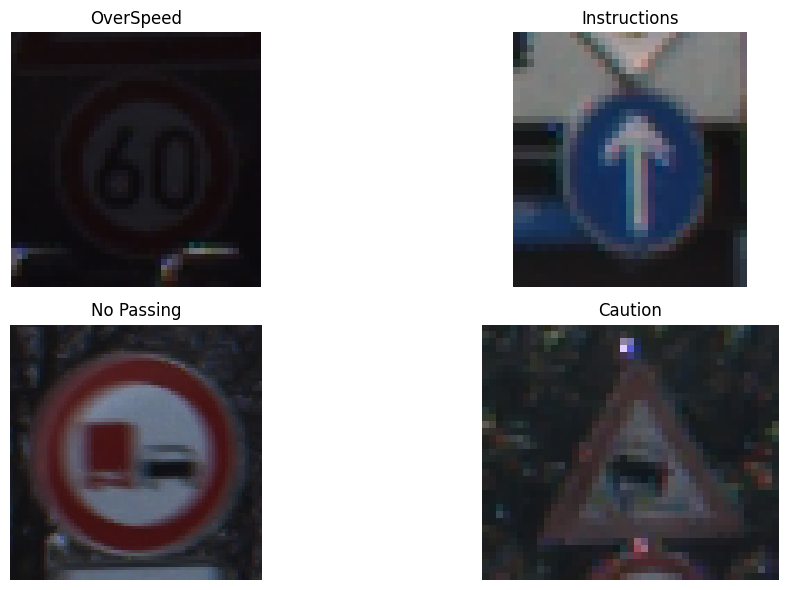

In [ ]:
visualize_data(train_dir)

**Distribution of Images per Label**

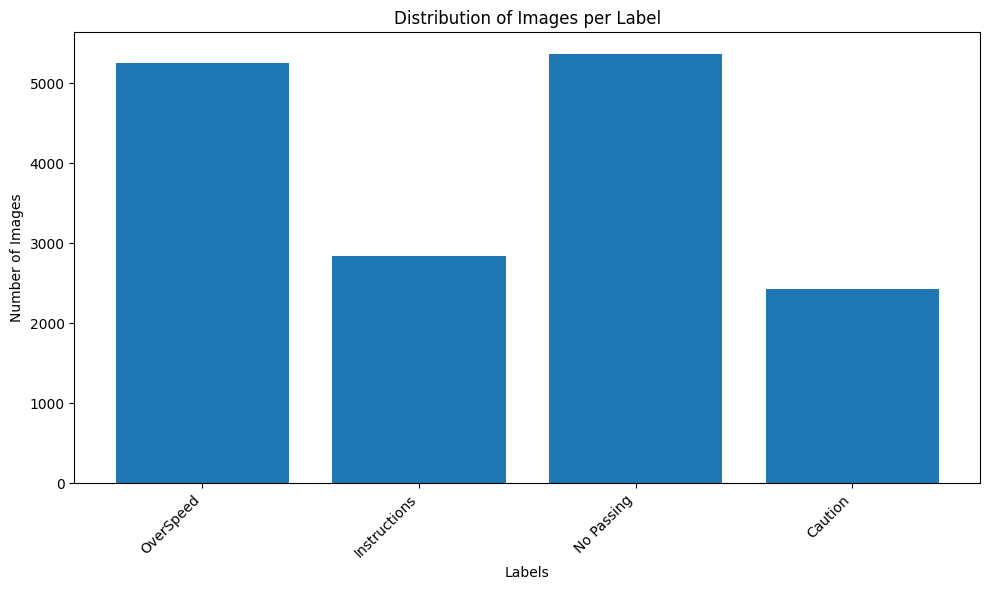

In [ ]:
label_counts = {}
for label_folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, label_folder)
    if os.path.isdir(folder_path):
        num_images = len([
            f for f in os.listdir(folder_path)
            if os.path.isfile(os.path.join(folder_path, f))
        ])
        label_counts[label_folder] = num_images

labels = list(label_counts.keys())
counts = list(label_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts)
plt.xlabel("Labels")
plt.ylabel("Number of Images")
plt.title("Distribution of Images per Label")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

### **Check Corrupted Images**

In [ ]:
import os
from PIL import Image

def check_and_remove_corrupted_images(train_folder):
        corrupted_images = []
        for class_dir in os.listdir(train_folder):
            class_path = os.path.join(train_folder, class_dir)
            if os.path.isdir(class_path):
                for image_file in os.listdir(class_path):
                    image_path = os.path.join(class_path, image_file)
                    try:
                        with Image.open(image_path) as img:
                            # Verify image format
                            img.verify()
                    except (IOError, SyntaxError) as e:
                        corrupted_images.append(image_path)
                        os.remove(image_path)
                        print(f"Removed corrupted image: {image_path}")

        if not corrupted_images:
            print("No corrupted images found.")
        else:
            print(f"Total corrupted images removed: {len(corrupted_images)}")


check_and_remove_corrupted_images(train_dir)

Removed corrupted image: /content/Traffic/Traffic_Sign/Train/OverSpeed/00005_00058_00027.png
Removed corrupted image: /content/Traffic/Traffic_Sign/Train/OverSpeed/00004_00005_00020.png
Removed corrupted image: /content/Traffic/Traffic_Sign/Train/OverSpeed/00004_00058_00025.png
Removed corrupted image: /content/Traffic/Traffic_Sign/Train/OverSpeed/00004_00057_00006.png
Removed corrupted image: /content/Traffic/Traffic_Sign/Train/OverSpeed/00005_00009_00027.png
Removed corrupted image: /content/Traffic/Traffic_Sign/Train/OverSpeed/00005_00035_00027.png
Removed corrupted image: /content/Traffic/Traffic_Sign/Train/OverSpeed/00005_00043_00008.png
Removed corrupted image: /content/Traffic/Traffic_Sign/Train/Instructions/00033_00015_00004.png
Removed corrupted image: /content/Traffic/Traffic_Sign/Train/Instructions/00035_00019_00013.png
Removed corrupted image: /content/Traffic/Traffic_Sign/Train/Instructions/00028_00013_00012.png
Removed corrupted image: /content/Traffic/Traffic_Sign/Train/

**Total Images on Train & Test after Removing Corrupted images**

In [ ]:
# Function to count images in a directory
def count_images(directory):
    image_count = 0
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', 'A.jpg', '.jpeg')):  # Add more extensions if needed
                image_count += 1
    return image_count

# Count images in train and test directories
train_image_count = count_images(train_dir)
test_image_count = count_images(test_dir)

# Print the results
print(f"Total images in train folder: {train_image_count}")
print(f"Total images in test folder: {test_image_count}")

Total images in train folder: 15867
Total images in test folder: 4


## **Data Loading and Preprocessing**

In [ ]:
import tensorflow as tf

# Constants
img_height = 128
img_width = 128
batch_size = 32
seed = 123

# Load full dataset (no split)
full_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    seed=seed
)

# Normalize
rescale = tf.keras.layers.Rescaling(1./255)
full_ds = full_ds.map(lambda x, y: (rescale(x), y))

# Count total batches
total_batches = tf.data.experimental.cardinality(full_ds).numpy()
test_split = int(0.2 * total_batches)  # 20% for test
train_val_split = total_batches - test_split  # 80%

# Split into train_val and test
train_val_ds = full_ds.take(train_val_split)
test_ds = full_ds.skip(train_val_split)

# Now split train_val into train (80%) and val (20%)
train_split = int(0.8 * train_val_split)
val_split = train_val_split - train_split

train_ds = train_val_ds.take(train_split)
val_ds = train_val_ds.skip(train_split)

Found 15867 files belonging to 4 classes.


## **Design, Train, and Evaluate a Baseline Model**

### **Base Model**

**Baseline CNN Model Architecture**

In [ ]:
model = tf.keras.models.Sequential([
      tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(img_height, img_width, 3)),
      tf.keras.layers.MaxPooling2D((2, 2)),
      tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
      tf.keras.layers.MaxPooling2D((2, 2)),
      tf.keras.layers.Flatten(),
      tf.keras.layers.Dense(64, activation='relu'),
      tf.keras.layers.Dense(128, activation='relu'),
      tf.keras.layers.Dense(4, activation='softmax') # 4 for 4 classes of traffic
])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,196 (8.07 MB)

 Trainable params: 2,116,196 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

**Adam Optimizer**

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), # from_logits=False because we use softmax
              metrics=['accuracy'])


**Model Training**

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define callbacks
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Fit the model
history = model.fit(
    train_ds,
    epochs=20,  # You can adjust the number of epochs
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping]
)


Epoch 1/20
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7685 - loss: 0.5744

317/317 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.7693 - loss: 0.5726 - val_accuracy: 0.9801 - val_loss: 0.0603
Epoch 2/20
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9829 - loss: 0.0547

317/317 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.9829 - loss: 0.0547 - val_accuracy: 0.9914 - val_loss: 0.0342
Epoch 3/20
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9940 - loss: 0.0218

317/317 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9940 - loss: 0.0218 - val_accuracy: 0.9934 - val_loss: 0.0352
Epoch 4/20
317/317 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.9943 - loss: 0.0247 - val_accuracy: 0.9867 - val_loss: 0.0491
Epoch 5/20
313/317 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9956 - loss: 0.0123

317/317 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9955 - loss: 0.0124 - val_accuracy: 0.9937 - val_loss: 0.0332
Epoch 6/20
313/317 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9921 - loss: 0.0247

317/317 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9921 - loss: 0.0247 - val_accuracy: 0.9945 - val_loss: 0.0276
Epoch 7/20
317/317 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.9993 - loss: 0.0030 - val_accuracy: 0.9945 - val_loss: 0.0279
Epoch 8/20
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9999 - loss: 5.7775e-04

317/317 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9999 - loss: 5.7786e-04 - val_accuracy: 0.9961 - val_loss: 0.0238
Epoch 9/20
317/317 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 1.0000 - loss: 1.9130e-04 - val_accuracy: 0.9953 - val_loss: 0.0352
Epoch 10/20
317/317 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 1.0000 - loss: 7.1002e-05 - val_accuracy: 0.9957 - val_loss: 0.0325
Epoch 11/20
317/317 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 1.0000 - loss: 5.2907e-05 - val_accuracy: 0.9957 - val_loss: 0.0351
Epoch 12/20
317/317 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 1.0000 - loss: 3.8226e-05 - val_accuracy: 0.9953 - val_loss: 0.0365
Epoch 13/20
317/317 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 1.0000 - loss: 2.7165e-05 - val_accuracy: 0.9957 - val_loss: 0.0385


**Visualization**

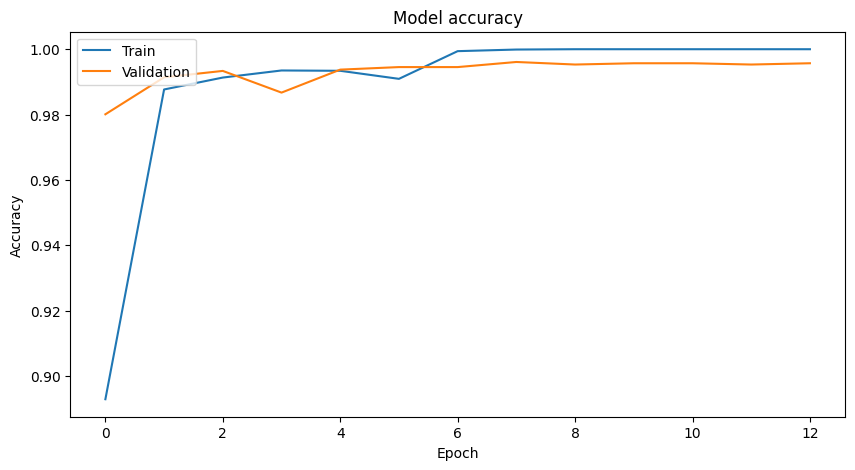

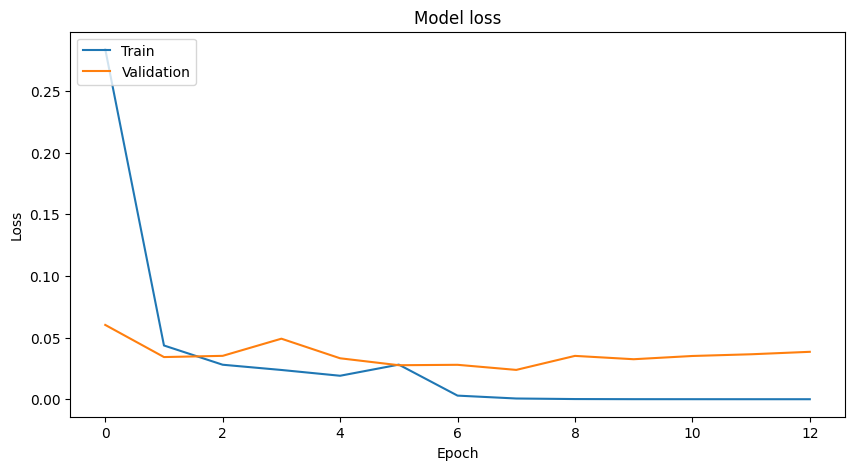

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


**Model Evaluation**

In [ ]:
# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(test_ds)

print('Test Loss:', loss)
print('Test Accuracy:', accuracy)

99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9958 - loss: 0.0248
Test Loss: 0.023630792275071144
Test Accuracy: 0.9952576756477356


**Prediction and Label Extraction Process**

In [ ]:
import numpy as np

# Extract true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

**Confusion Matrix**

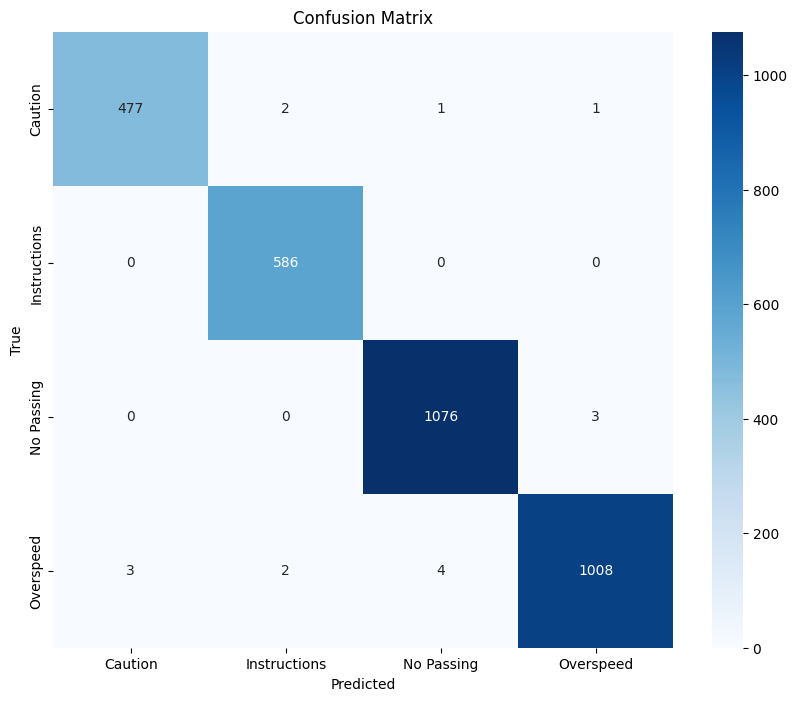

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))

# Assuming class_dirs was defined in a previous cell or during visualization,
# if not, define it here with your class names
class_dirs = ['Caution', 'Instructions', 'No Passing', 'Overspeed'] # Replace with your actual class names if needed

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_dirs,
            yticklabels=class_dirs)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

**Classification Report**

In [ ]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_dirs))

Classification Report:

              precision    recall  f1-score   support

     Caution       0.99      0.99      0.99       481
Instructions       0.99      1.00      1.00       586
  No Passing       1.00      1.00      1.00      1079
   Overspeed       1.00      0.99      0.99      1017

    accuracy                           0.99      3163
   macro avg       0.99      1.00      0.99      3163
weighted avg       0.99      0.99      0.99      3163



### **Design, Train , and Evaluate Deeper Architecture with Regularization Layer**

### **Batch Normalization and Dropout**

**Adam Optimizer**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# Define data augmentation layers using a Sequential model
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"), # Flip both horizontally and vertically
    layers.RandomRotation(0.2), # Increase the rotation range
    layers.RandomZoom(0.2), # Add random zoom
    layers.RandomContrast(0.2) # Add random contrast adjustment
], name="data_augmentation")

In [ ]:
# Define the main CNN model
modelcnn2 = keras.Sequential([
    # Apply data augmentation directly
    data_augmentation,

    # Rescaling layer to normalize pixel values
    # layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same",input_shape=(128, 128, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Deeper Model Architecture**

In [ ]:
import tensorflow as tf

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
modelcnn2.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Get a batch of images and labels from the training dataset
for images, labels in train_ds.take(1):  # Take 1 batch
    break

# Display model summary
modelcnn2.predict(images, verbose=0)  # Predict on the batch of images
modelcnn2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (32, 128, 128, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 128, 128, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (32, 128, 128, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 64, 64, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 64, 64, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 64, 64, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (32, 64, 64, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 32, 32, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (32, 32, 32, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 32, 32, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (32, 32, 32, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 16, 16, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (32, 16, 16, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 32768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 256)              │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (32, 256)              │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (32, 4)                │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,485,060 (32.37 MB)

 Trainable params: 8,484,100 (32.36 MB)

 Non-trainable params: 960 (3.75 KB)

**Model Training**

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define callbacks
callbacks = [
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)
]

# Train the model
cnn_history = modelcnn2.fit(
    train_ds,  # Training dataset
    validation_data=val_ds,  # Validation dataset
    epochs=250,  # Number of epochs
    batch_size=32,  # Batch size
    callbacks=callbacks  # Callbacks for early stopping and saving the best model
)

Epoch 1/250
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5784 - loss: 1.2227
Epoch 1: val_loss improved from inf to 5.32587, saving model to best_model.h5


317/317 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.5787 - loss: 1.2217 - val_accuracy: 0.3559 - val_loss: 5.3259
Epoch 2/250
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8073 - loss: 0.5208
Epoch 2: val_loss improved from 5.32587 to 1.71973, saving model to best_model.h5


317/317 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.8073 - loss: 0.5207 - val_accuracy: 0.7074 - val_loss: 1.7197
Epoch 3/250
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8603 - loss: 0.3846
Epoch 3: val_loss improved from 1.71973 to 1.63472, saving model to best_model.h5


317/317 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step - accuracy: 0.8604 - loss: 0.3845 - val_accuracy: 0.8266 - val_loss: 1.6347
Epoch 4/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8899 - loss: 0.3023
Epoch 4: val_loss did not improve from 1.63472
317/317 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.8899 - loss: 0.3022 - val_accuracy: 0.8602 - val_loss: 1.6640
Epoch 5/250
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8976 - loss: 0.2894
Epoch 5: val_loss improved from 1.63472 to 0.82456, saving model to best_model.h5


317/317 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - accuracy: 0.8977 - loss: 0.2893 - val_accuracy: 0.8988 - val_loss: 0.8246
Epoch 6/250
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9150 - loss: 0.2373
Epoch 6: val_loss improved from 0.82456 to 0.53906, saving model to best_model.h5


...

317/317 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.9436 - loss: 0.1555 - val_accuracy: 0.9637 - val_loss: 0.1184
Epoch 11/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9522 - loss: 0.1383
Epoch 11: val_loss improved from 0.11841 to 0.10790, saving model to best_model.h5


317/317 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.9522 - loss: 0.1383 - val_accuracy: 0.9680 - val_loss: 0.1079
Epoch 12/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9543 - loss: 0.1300
Epoch 12: val_loss did not improve from 0.10790
317/317 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.9543 - loss: 0.1300 - val_accuracy: 0.9492 - val_loss: 0.2347
Epoch 13/250
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9620 - loss: 0.1102
Epoch 13: val_loss improved from 0.10790 to 0.06423, saving model to best_model.h5


317/317 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - accuracy: 0.9620 - loss: 0.1102 - val_accuracy: 0.9801 - val_loss: 0.0642
Epoch 14/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9641 - loss: 0.1033
Epoch 14: val_loss improved from 0.06423 to 0.05967, saving model to best_model.h5


317/317 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - accuracy: 0.9641 - loss: 0.1033 - val_accuracy: 0.9789 - val_loss: 0.0597
Epoch 15/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9643 - loss: 0.0980
Epoch 15: val_loss did not improve from 0.05967
317/317 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step - accuracy: 0.9643 - loss: 0.0980 - val_accuracy: 0.9770 - val_loss: 0.0602
Epoch 16/250
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9656 - loss: 0.0928
Epoch 16: val_loss did not improve from 0.05967
317/317 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - accuracy: 0.9656 - loss: 0.0928 - val_accuracy: 0.9816 - val_loss: 0.0855
Epoch 17/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9665 - loss: 0.0905
Epoch 17: val_loss improved from 0.05967 to 0.05268, saving model to best_model.h5


317/317 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9665 - loss: 0.0905 - val_accuracy: 0.9832 - val_loss: 0.0527
Epoch 18/250
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9712 - loss: 0.0800
Epoch 18: val_loss did not improve from 0.05268
317/317 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.9712 - loss: 0.0800 - val_accuracy: 0.9379 - val_loss: 0.3446
Epoch 19/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9740 - loss: 0.0759
Epoch 19: val_loss did not improve from 0.05268
317/317 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.9740 - loss: 0.0759 - val_accuracy: 0.9133 - val_loss: 0.6752
Epoch 20/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9751 - loss: 0.0810
Epoch 20: val_loss did not improve from 0.05268
317/317 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.9751 - loss: 0.0810 - val_accuracy: 0.7945 - val_loss: 4.3514
Epoch 21/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9725 - loss: 0.0899
Epoch 21: val_loss did n

**Model Evaluation**

In [ ]:
# Evaluate the model on the test dataset
loss, accuracy = modelcnn2.evaluate(test_ds)

print('Test Loss:', loss)
print('Test Accuracy:', accuracy)

99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9870 - loss: 0.0395
Test Loss: 0.04879538714885712
Test Accuracy: 0.9851406812667847


**Visualization**

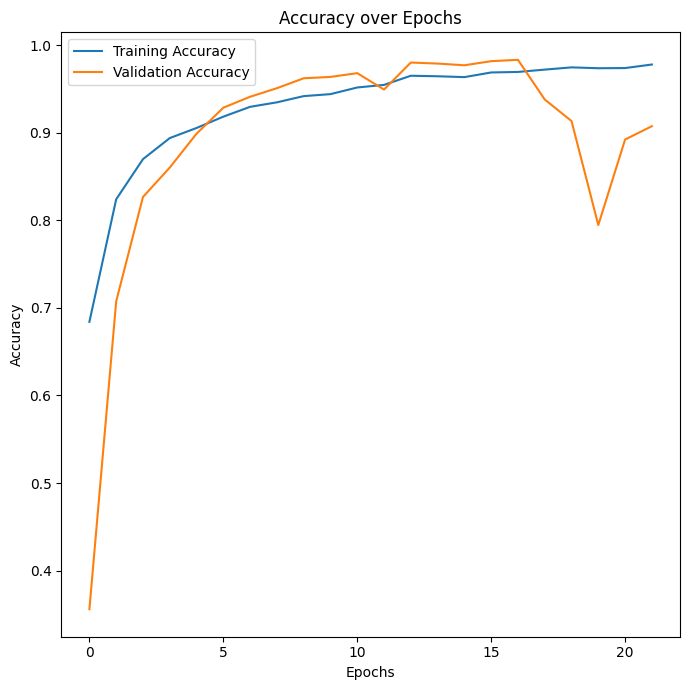

In [ ]:
# Plot training and validation accuracy
plt.figure(figsize=(7, 7))
# Accuracy plot

plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

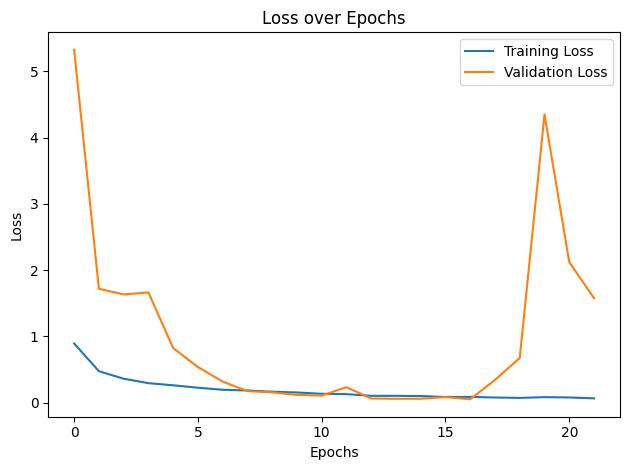

In [ ]:
# Loss plot
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

**Prediction and Label Extraction Process**

In [ ]:
import numpy as np

# Extract true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = modelcnn2.predict(images, verbose=0)  # <--- suppress output
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

**Confusion Matrix**

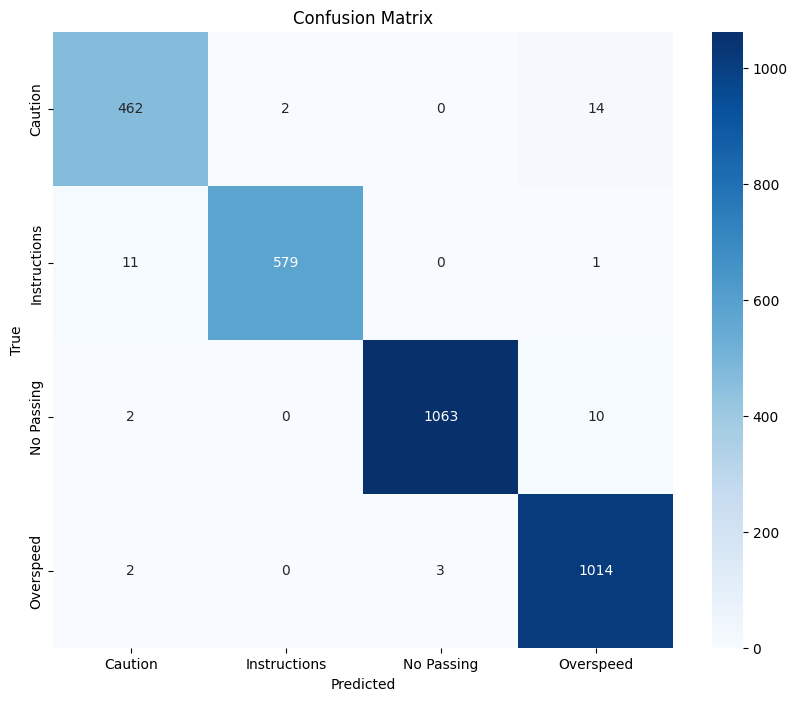

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_dirs,
            yticklabels=class_dirs)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


**Classification Report**

In [ ]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_dirs))

Classification Report:

              precision    recall  f1-score   support

     Caution       0.97      0.97      0.97       478
Instructions       1.00      0.98      0.99       591
  No Passing       1.00      0.99      0.99      1075
   Overspeed       0.98      1.00      0.99      1019

    accuracy                           0.99      3163
   macro avg       0.98      0.98      0.98      3163
weighted avg       0.99      0.99      0.99      3163



**SGD Optimizer**

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
modelcnn2.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])


In [ ]:
# Compile the model with the SGD optimizer
modelcnn2.compile(optimizer=optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Get and display the model summary
modelcnn2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (32, 128, 128, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 128, 128, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (32, 128, 128, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 64, 64, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 64, 64, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 64, 64, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (32, 64, 64, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 32, 32, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (32, 32, 32, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 32, 32, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (32, 32, 32, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 16, 16, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (32, 16, 16, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 32768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 256)              │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (32, 256)              │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (32, 4)                │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,485,060 (32.37 MB)

 Trainable params: 8,484,100 (32.36 MB)

 Non-trainable params: 960 (3.75 KB)

**Model Training**

In [ ]:
# Define callbacks
callbacks = [
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)
]
cnn_history = modelcnn2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8755 - loss: 0.3848
Epoch 1: val_loss improved from inf to 1.42929, saving model to best_model.h5


317/317 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.8757 - loss: 0.3840 - val_accuracy: 0.7953 - val_loss: 1.4293
Epoch 2/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9288 - loss: 0.1997
Epoch 2: val_loss improved from 1.42929 to 0.38746, saving model to best_model.h5


317/317 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.9288 - loss: 0.1995 - val_accuracy: 0.9289 - val_loss: 0.3875
Epoch 3/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9456 - loss: 0.1500
Epoch 3: val_loss did not improve from 0.38746
317/317 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.9456 - loss: 0.1499 - val_accuracy: 0.7586 - val_loss: 3.7309
Epoch 4/250
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9628 - loss: 0.1144
Epoch 4: val_loss did not improve from 0.38746
317/317 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - accuracy: 0.9628 - loss: 0.1144 - val_accuracy: 0.9293 - val_loss: 0.9230
Epoch 5/250
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9644 - loss: 0.0971
Epoch 5: val_loss improved from 0.38746 to 0.17234, saving model to best_model.h5


317/317 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9644 - loss: 0.0971 - val_accuracy: 0.9602 - val_loss: 0.1723
Epoch 6/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9569 - loss: 0.1243
Epoch 6: val_loss improved from 0.17234 to 0.10352, saving model to best_model.h5


317/317 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.9569 - loss: 0.1242 - val_accuracy: 0.9711 - val_loss: 0.1035
Epoch 7/250
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9615 - loss: 0.1071
Epoch 7: val_loss improved from 0.10352 to 0.08656, saving model to best_model.h5


...

317/317 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.9706 - loss: 0.0811 - val_accuracy: 0.9746 - val_loss: 0.0702
Epoch 14/250
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9728 - loss: 0.0857
Epoch 14: val_loss improved from 0.07023 to 0.06194, saving model to best_model.h5


317/317 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.9728 - loss: 0.0857 - val_accuracy: 0.9812 - val_loss: 0.0619
Epoch 15/250
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9810 - loss: 0.0611
Epoch 15: val_loss improved from 0.06194 to 0.05060, saving model to best_model.h5


317/317 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.9810 - loss: 0.0611 - val_accuracy: 0.9836 - val_loss: 0.0506
Epoch 16/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9703 - loss: 0.0852
Epoch 16: val_loss did not improve from 0.05060
317/317 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.9702 - loss: 0.0853 - val_accuracy: 0.9711 - val_loss: 0.0890
Epoch 17/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9651 - loss: 0.1036
Epoch 17: val_loss did not improve from 0.05060
317/317 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.9651 - loss: 0.1035 - val_accuracy: 0.9836 - val_loss: 0.0515
Epoch 18/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9701 - loss: 0.0800
Epoch 18: val_loss improved from 0.05060 to 0.04455, saving model to best_model.h5


317/317 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.9701 - loss: 0.0800 - val_accuracy: 0.9855 - val_loss: 0.0446
Epoch 19/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9749 - loss: 0.0744
Epoch 19: val_loss did not improve from 0.04455
317/317 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.9749 - loss: 0.0744 - val_accuracy: 0.9727 - val_loss: 0.1106
Epoch 20/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9765 - loss: 0.0672
Epoch 20: val_loss did not improve from 0.04455
317/317 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.9765 - loss: 0.0672 - val_accuracy: 0.9801 - val_loss: 0.0610
Epoch 21/250
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9825 - loss: 0.0599
Epoch 21: val_loss did not improve from 0.04455
317/317 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.9825 - loss: 0.0599 - val_accuracy: 0.9879 - val_loss: 0.0451
Epoch 22/250
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9755 - loss: 0.0710
Epoch 22: val_loss did n

317/317 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.9744 - loss: 0.0686 - val_accuracy: 0.9887 - val_loss: 0.0329
Epoch 24/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9811 - loss: 0.0555
Epoch 24: val_loss did not improve from 0.03292
317/317 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.9811 - loss: 0.0556 - val_accuracy: 0.9777 - val_loss: 0.0684
Epoch 25/250
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9826 - loss: 0.0586
Epoch 25: val_loss did not improve from 0.03292
317/317 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.9826 - loss: 0.0586 - val_accuracy: 0.9578 - val_loss: 0.2487
Epoch 26/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9790 - loss: 0.0602
Epoch 26: val_loss did not improve from 0.03292
317/317 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.9790 - loss: 0.0602 - val_accuracy: 0.9930 - val_loss: 0.0338
Epoch 27/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9883 - loss: 0.0439
Epoch 27: val_loss did n

**Model Evaluation**

In [ ]:
# Evaluate the model on the test dataset
loss, accuracy = modelcnn2.evaluate(test_ds)

print('Test Loss:', loss)
print('Test Accuracy:', accuracy)

99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9909 - loss: 0.0297
Test Loss: 0.024212608113884926
Test Accuracy: 0.9917799830436707


**Visualization**

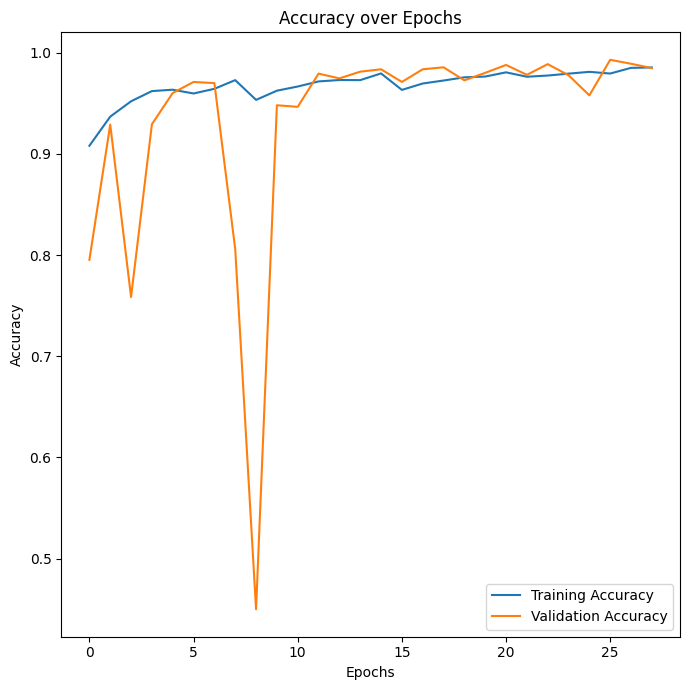

In [ ]:
# Plot training and validation accuracy
plt.figure(figsize=(7, 7))
# Accuracy plot

plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

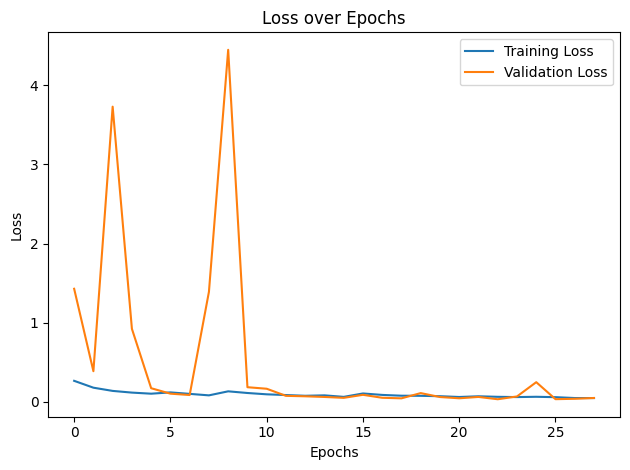

In [ ]:
# Loss plot
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

**Prediction and Label Extraction Process**

In [ ]:
import numpy as np

# Extract true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = modelcnn2.predict(images, verbose=0)  # <--- suppress output
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

**Confusion Matrix**

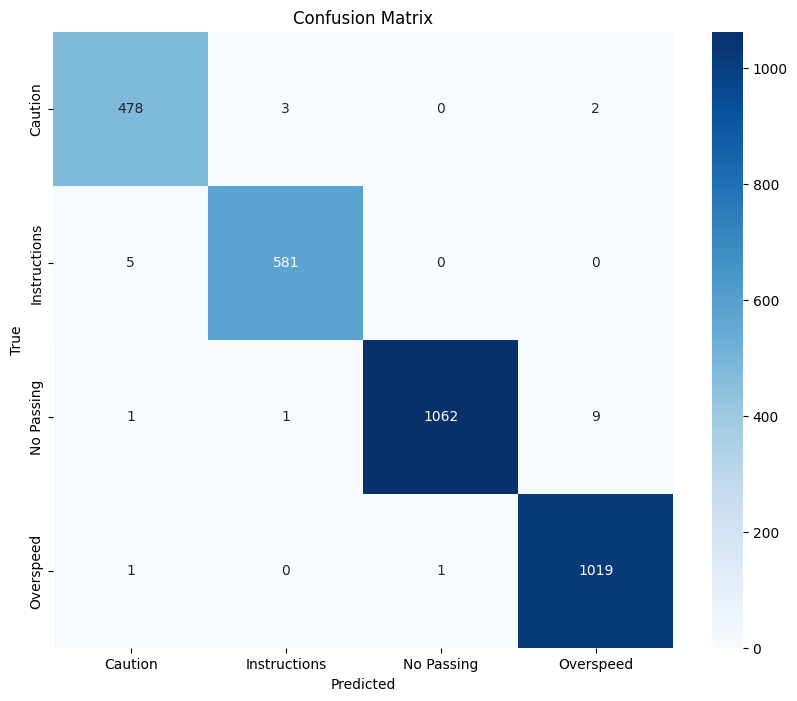

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_dirs,
            yticklabels=class_dirs)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


**Classification Report**

In [ ]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_dirs))

Classification Report:

              precision    recall  f1-score   support

     Caution       0.99      0.99      0.99       483
Instructions       0.99      0.99      0.99       586
  No Passing       1.00      0.99      0.99      1073
   Overspeed       0.99      1.00      0.99      1021

    accuracy                           0.99      3163
   macro avg       0.99      0.99      0.99      3163
weighted avg       0.99      0.99      0.99      3163



# **Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)**

### **MobilenetV2**

**Loading and Adapting a Pre - Trained Model**

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input

# Define input shape
input_shape = (128, 128, 3)
base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')

# Freeze the base model
base_model.trainable = False

# Add custom layers on top
inputs = Input(shape=input_shape)
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(4, activation='softmax')(x)

# Create the model
modelnetv2 = Model(inputs, outputs)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Adam Optimizer**

In [ ]:
from tensorflow.keras.optimizers import Adam

modelnetv2.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


**Model Training**

In [ ]:
vnet2_history = modelnetv2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=callbacks
)


Epoch 1/250
315/317 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8388 - loss: 0.4162
Epoch 1: val_loss did not improve from 0.03292
317/317 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.8395 - loss: 0.4146 - val_accuracy: 0.9633 - val_loss: 0.1026
Epoch 2/250
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9535 - loss: 0.1230
Epoch 2: val_loss did not improve from 0.03292
317/317 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9535 - loss: 0.1230 - val_accuracy: 0.9746 - val_loss: 0.0727
Epoch 3/250
315/317 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9633 - loss: 0.0950
Epoch 3: val_loss did not improve from 0.03292
317/317 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9633 - loss: 0.0950 - val_accuracy: 0.9727 - val_loss: 0.0686
Epoch 4/250
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9701 - loss: 0.0747
Epoch 4: val_loss did not improve from 0.03292
317/317 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9701 - loss: 0.0747 - val_accuracy: 0.9871 - val_

317/317 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9821 - loss: 0.0565 - val_accuracy: 0.9922 - val_loss: 0.0270
Epoch 6/250
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9804 - loss: 0.0599
Epoch 6: val_loss did not improve from 0.02699
317/317 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9804 - loss: 0.0599 - val_accuracy: 0.9859 - val_loss: 0.0376
Epoch 7/250
315/317 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9845 - loss: 0.0413
Epoch 7: val_loss did not improve from 0.02699
317/317 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9845 - loss: 0.0413 - val_accuracy: 0.9914 - val_loss: 0.0274
Epoch 8/250
314/317 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9838 - loss: 0.0486
Epoch 8: val_loss improved from 0.02699 to 0.01415, saving model to best_model.h5


317/317 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9837 - loss: 0.0486 - val_accuracy: 0.9957 - val_loss: 0.0141
Epoch 9/250
315/317 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9881 - loss: 0.0367
Epoch 9: val_loss did not improve from 0.01415
317/317 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9881 - loss: 0.0367 - val_accuracy: 0.9953 - val_loss: 0.0168
Epoch 10/250
314/317 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9897 - loss: 0.0283
Epoch 10: val_loss did not improve from 0.01415
317/317 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.9897 - loss: 0.0283 - val_accuracy: 0.9937 - val_loss: 0.0167
Epoch 11/250
313/317 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9908 - loss: 0.0284
Epoch 11: val_loss did not improve from 0.01415
317/317 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9908 - loss: 0.0285 - val_accuracy: 0.9902 - val_loss: 0.0277
Epoch 12/250
315/317 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9842 - loss: 0.0411
Epoch 12: val_loss did not 

In [ ]:
modelnetv2.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,751,438 (10.50 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 328,970 (1.25 MB)

In [ ]:
import tensorflow as tf
import os
import numpy as np

# Path to your test directory
test_dir = "/content/Traffic/Traffic_Sign/Test"

# Load and preprocess the test images manually
test_images = []
image_names = []

for fname in os.listdir(test_dir):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
        img_path = os.path.join(test_dir, fname)
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(img_height, img_width))
        img = tf.keras.preprocessing.image.img_to_array(img)
        img = rescale(img)  # Apply the same rescaling you used during training
        test_images.append(img)
        image_names.append(fname)

# Convert list to numpy array
test_images = np.array(test_images)

# Make predictions
pred_probs = modelnetv2.predict(test_images)
pred_labels = np.argmax(pred_probs, axis=1)  # Convert to class indices


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


**Model Evaluating**

In [ ]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = modelnetv2.evaluate(test_ds)
print(f"\n\nTest Loss: {test_loss:.4f}\nTest Accuracy: {test_accuracy:.4f}")

99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.9944 - loss: 0.0201


Test Loss: 0.0207
Test Accuracy: 0.9940


**Visualization**

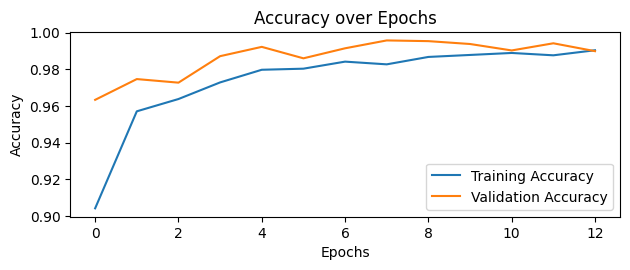

In [ ]:
# Accuracy plot
plt.subplot(2, 1, 1)
plt.plot(vnet2_history.history['accuracy'], label='Training Accuracy')
plt.plot(vnet2_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


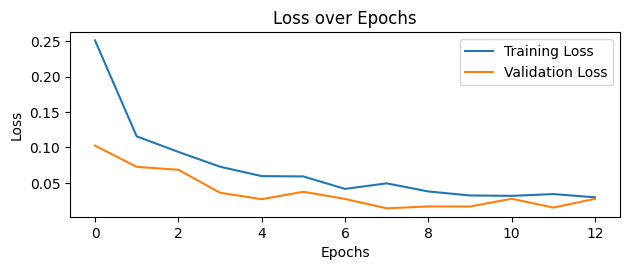

In [ ]:
# Loss plot
plt.subplot(2, 1, 2)
plt.plot(vnet2_history.history['loss'], label='Training Loss')
plt.plot(vnet2_history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# **Model Evaluation**

In [ ]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support  # Import the function

# Evaluate the base model
base_model_loss, base_model_accuracy = model.evaluate(test_ds)

# Evaluate the model with SGD optimizer
sgd_loss, sgd_accuracy = modelcnn2.evaluate(test_ds)  # Assuming modelcnn2 is the model with SGD

# Evaluate the model with Adam optimizer
adam_loss, adam_accuracy = modelcnn2.evaluate(test_ds)  # Assuming modelcnn2 is the model with Adam

# Evaluate the MobileNetV2 model
mobilenetv2_loss, mobilenetv2_accuracy = modelnetv2.evaluate(test_ds)

# Function to calculate and store metrics
def evaluate_and_store_metrics(model, test_ds, model_name, data_dict):
    # Evaluate the model
    loss, accuracy = model.evaluate(test_ds)

    # Extract true labels and predictions
    y_true = []
    y_pred = []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())

    # Calculate precision, recall, and F1-score (macro average)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

    # Store the metrics in the dictionary
    data_dict['Model'].append(model_name)
    data_dict['Accuracy'].append(accuracy)
    data_dict['Loss'].append(loss)
    data_dict['Precision'].append(precision)
    data_dict['Recall'].append(recall)
    data_dict['F1-score'].append(f1)

# Initialize the dictionary
data = {
    'Model': [],
    'Accuracy': [],
    'Loss': [],
    'Precision': [],
    'Recall': [],
    'F1-score': []
}

# Evaluate and store metrics for each model
evaluate_and_store_metrics(model, test_ds, 'Base Model', data)
evaluate_and_store_metrics(modelcnn2, test_ds, 'SGD', data)  # Assuming modelcnn2 is the model with SGD
evaluate_and_store_metrics(modelcnn2, test_ds, 'Adam', data)  # Assuming modelcnn2 is the model with Adam
evaluate_and_store_metrics(modelnetv2, test_ds, 'MobileNetV2', data)

# Create a pandas DataFrame from the dictionary
df = pd.DataFrame(data)

# Display the table
display(df)

99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9953 - loss: 0.0277
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9916 - loss: 0.0269
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9934 - loss: 0.0211
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9940 - loss: 0.0210
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9942 - loss: 0.0230
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9940 - loss: 0.0184
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9918 - loss: 0.0256
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9934 - loss: 0.0213


,Model,Accuracy,Loss,Precision,Recall,F1-score
0,Base Model,0.994942,0.023563,0.994841,0.995296,0.995063
1,SGD,0.992096,0.022301,0.990870,0.991222,0.991037
2,Adam,0.991780,0.023852,0.991267,0.991729,0.991484
3,MobileNetV2,0.993677,0.020863,0.993880,0.993529,0.993701


# **Predicting with One test Image**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


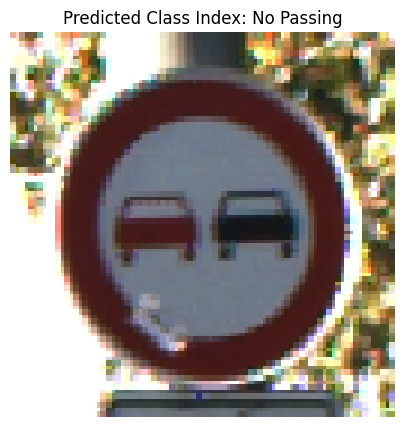

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# Path to your image
image_path = '/content/Traffic/Traffic_Sign/Test/00009_00001_00027.png' # Replace with your image path

# Load and preprocess the image
img = image.load_img(image_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
img_array = img_array / 255.0  # Normalize pixel values

# Make prediction
prediction = modelcnn2.predict(img_array)

# Get predicted class index
predicted_class_index = np.argmax(prediction[0])

# Map predicted class index to label name
class_dirs = ['Caution', 'Instructions', 'No Passing', 'Overspeed'] # Order is important!
predicted_class_label = class_dirs[predicted_class_index]

# Display the image with smaller size
plt.figure(figsize=(5, 5))  # Adjust figsize for desired size
plt.imshow(img)
plt.title(f"Predicted Class Index: {predicted_class_label}")
plt.axis('off')  # Hide axes
plt.show()
